#### **Project : Network Traffic Anomaly Detection using GMM**

#### **Objective :**

The objective of this project is to analyze network traffic data and identify hidden behavioral patterns using Gaussian Mixture Models (GMM).

The key goals of this project are:

- To analyze network traffic features such as packet size, request frequency, and connection duration.
- To perform exploratory data analysis (EDA) to understand traffic patterns and distributions.
- To apply feature scaling for distance-based modeling.
- To determine the optimal number of Gaussian components using BIC and AIC.
- To build a Gaussian Mixture Model for probabilistic clustering of network traffic.
- To calculate the probability of each data point belonging to different clusters.
- To detect anomalies in network traffic using anomaly scores.
- To classify traffic into Normal and Suspicious categories.
- To create meaningful cybersecurity segments such as high-risk, moderate-risk, and normal traffic.
- To support early detection of suspicious activities and improve network security monitoring.

In [1]:
# Step 1 : Import Required Libraries 

import os                           # To create folders 
import warnings                     # To hide warnings
import numpy as np                 # For numerical operations
import pandas as pd               # For data manipulation
import matplotlib.pyplot as plt     # For data visualization
import seaborn as sns               # For advanced data visualization

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score , davies_bouldin_score , calinski_harabasz_score

warnings.filterwarnings('ignore')        # To ignore warnings
os.makedirs("images", exist_ok=True)  # To create a folder for images if it doesn't exist

In [2]:
# Step 2 : Load the Dataset 
df = pd.read_csv("network_traffic_data.csv")  # Load the dataset
print("Dataset Loaded Successfully!")

print(df.head())  # Display the first few rows of the dataset
print(df.info())  # Display information about the dataset
print(df.describe())  # Display statistical summary of the dataset

Dataset Loaded Successfully!
   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  
0           2100  
1           2400  
2           3000  
3           3500  
4           4000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Packet_Size          96 non-null     int64
 1   Request_Frequency    96 non-null     int64
 2   Connection_Duration  96 non-null     int64
 3   Failed_Logins        96 non-null     int64
 4   Data_Transfer        96

In [3]:
# Step 3 : Data Preprocessing 
print("\nMissing Values :\n",df.isnull().sum())  # Check for missing values
print("\nDuplicate Rows : ", df.duplicated().sum())  # Check for duplicate rows
df.drop_duplicates(inplace=True)  # Remove duplicate rows


Missing Values :
 Packet_Size            0
Request_Frequency      0
Connection_Duration    0
Failed_Logins          0
Data_Transfer          0
dtype: int64

Duplicate Rows :  0


In [4]:
# Step 4 : Select Important Network Features

# These features help us understand traffic behavior
features = [
    "Packet_Size",
    "Request_Frequency",
    "Connection_Duration",
    "Failed_Logins",
    "Data_Transfer"
]

X = df[features]  # Select the important features for analysis
print(X.head())  # Display the first few rows of the selected features

   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  
0           2100  
1           2400  
2           3000  
3           3500  
4           4000  


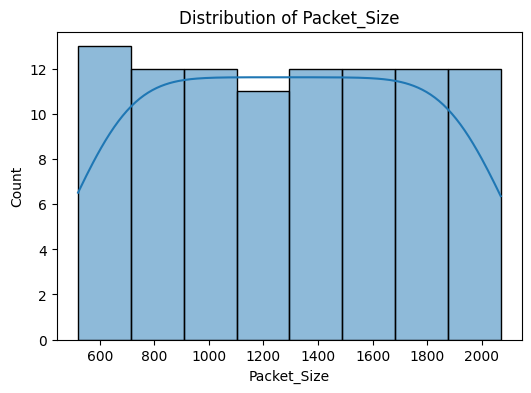

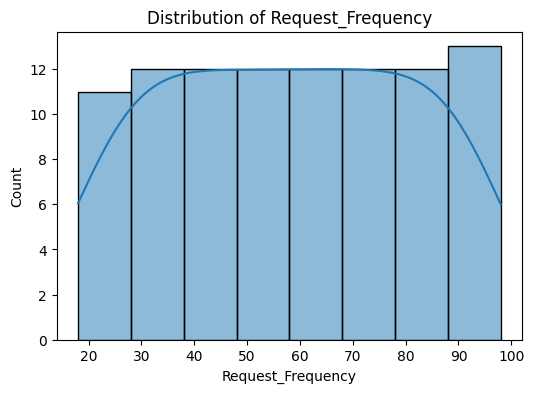

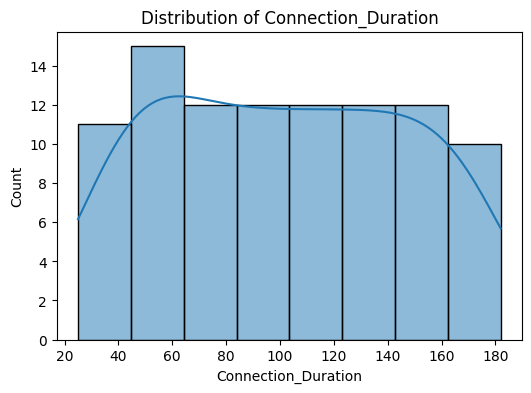

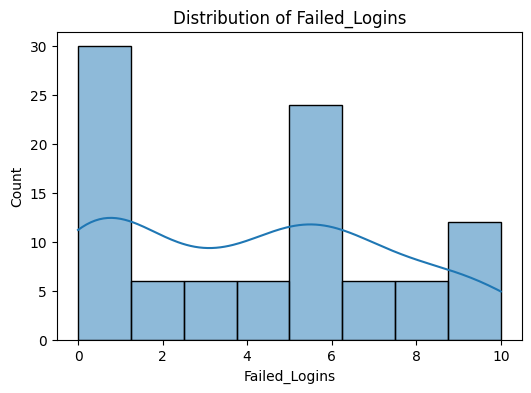

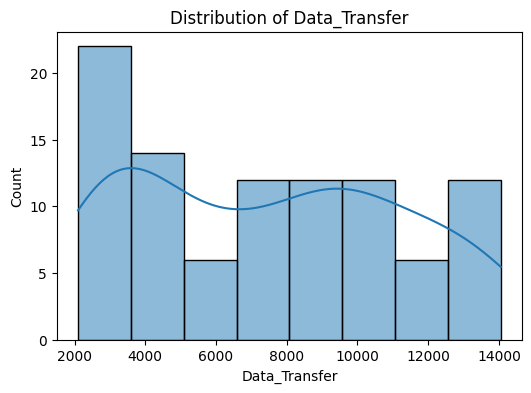

In [5]:
# Step 5 : Univariate EDA

# Understanding each feature separately.
for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.savefig(f"images/{col}_distribution.png")  # Save the plot
    plt.show()
    plt.close()

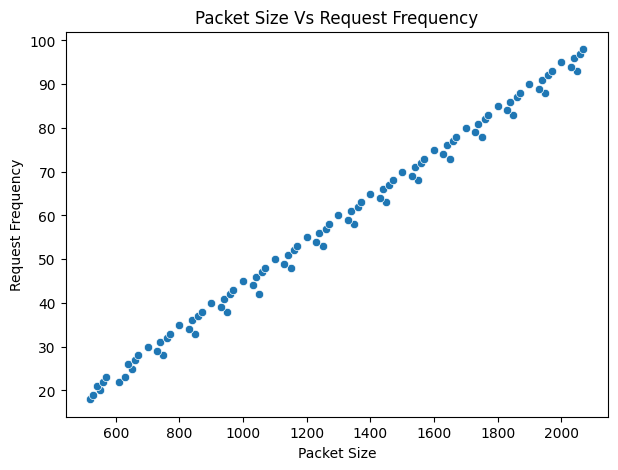

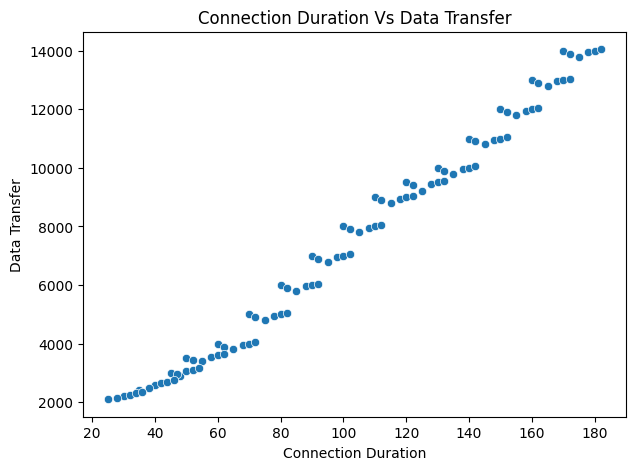

In [6]:
# Step 6 : Bivariate EDA

# Checking packet size and request begavior
plt.figure(figsize = (7,5))
sns.scatterplot(data = df , x = "Packet_Size" , y = "Request_Frequency")
plt.title("Packet Size Vs Request Frequency")
plt.xlabel("Packet Size")
plt.ylabel("Request Frequency")
plt.savefig("images/packet_size_vs_request_frequency.png")  # Save the plot
plt.show()
plt.close()

# Checking connection duration and data transfer .
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Connection_Duration", y="Data_Transfer")
plt.title("Connection Duration Vs Data Transfer")
plt.xlabel("Connection Duration")
plt.ylabel("Data Transfer")
plt.savefig("images/connection_duration_vs_data_transfer.png")  # Save the plot
plt.show()
plt.close()

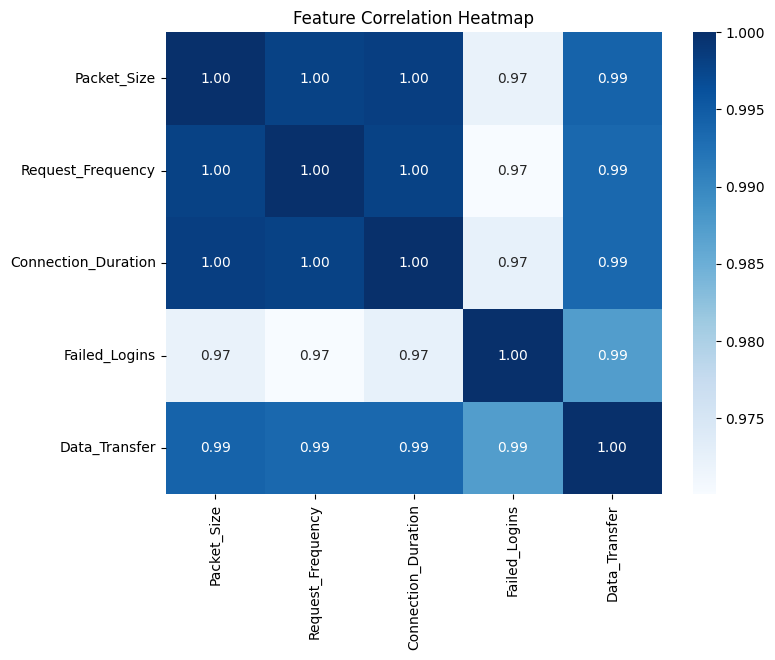

In [7]:
# Step 7 : Correlation Analysis 

# Checking relationship between network features 
plt.figure(figsize=(8,6))
sns.heatmap(X.corr() , annot=True, cmap="Blues" , fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("images/feature_correlation_heatmap.png" , dpi = 300)  # Save the plot
plt.show()
plt.close()

In [8]:
# Step 8 : Feature Scaling 

# Scaling is important because feature ranges are different
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale the features
print(X_scaled[:5])  # Display the first few rows of the scaled features

[[-1.67448049 -1.72647251 -1.7031132  -1.29834234 -1.42886123]
 [-1.47926377 -1.55369028 -1.48177996 -0.98829044 -1.34879274]
 [-1.28404704 -1.2081258  -1.26044671 -1.29834234 -1.18865575]
 [-1.06713957 -0.992148   -1.14978009 -0.98829044 -1.05520825]
 [-0.8502321  -0.77617021 -0.92844685 -1.29834234 -0.92176076]]


In [9]:
# Step 9 : Find Best Number of GMM Components

# BIC and AIC help choose the best number of hidden traffic groups 

results = [] 

for k in range(2 , 8):
    gmm = GaussianMixture(
        n_components = k,
        covariance_type="full",
        random_state=42
    )
    
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    
    results.append({
        "Components": k , 
        "BIC": round(gmm.bic(X_scaled) , 2 ),
        "AIC": round(gmm.aic(X_scaled) , 2 ),
        "silhouette_score": round(silhouette_score(X_scaled , labels) , 3),
        "Davies_Boulding_Score": round(davies_bouldin_score(X_scaled , labels) , 3 ),
        "calinski_harabasz_score": round(calinski_harabasz_score(X_scaled , labels) , 3) 
    })
    
    evaluation_df = pd.DataFrame(results)
    print(evaluation_df)
    
    evaluation_df.to_csv("gmm_evaluation_results.csv" , index=False)  # Save results to CSV

   Components     BIC     AIC  silhouette_score  Davies_Boulding_Score  \
0           2 -704.15 -809.29             0.498                  0.518   

   calinski_harabasz_score  
0                   131.96  
   Components     BIC      AIC  silhouette_score  Davies_Boulding_Score  \
0           2 -704.15  -809.29             0.498                  0.518   
1           3 -943.00 -1101.99             0.561                  0.536   

   calinski_harabasz_score  
0                  131.960  
1                  343.147  
   Components      BIC      AIC  silhouette_score  Davies_Boulding_Score  \
0           2  -704.15  -809.29             0.498                  0.518   
1           3  -943.00 -1101.99             0.561                  0.536   
2           4 -1140.29 -1353.13             0.390                  0.560   

   calinski_harabasz_score  
0                  131.960  
1                  343.147  
2                  274.884  
   Components      BIC      AIC  silhouette_score  Davies_B

In [10]:
best_k = evaluation_df.sort_values(
    by=["BIC", "silhouette_score"],
    ascending=[True, False]
).iloc[0]["Components"]

best_k = int(best_k)

print("Best Number of Components:", best_k)

Best Number of Components: 4


In [11]:
# Step 11 : Build Final GMM Model 

# GMM captures overlapping traffic behavior.
gmm_model = GaussianMixture(
    n_components= best_k,
    covariance_type="full",
    random_state=42
)

gmm_model.fit(X_scaled)  # Fit the GMM model to the scaled data
df["Cluster"] = gmm_model.predict(X_scaled)  # Assign cluster labels to the original dataframe

print(df.head())
print("\nCluster Counts :\n", df["Cluster"].value_counts())  # Display the count of samples in each cluster

   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  Cluster  
0           2100        0  
1           2400        0  
2           3000        0  
3           3500        0  
4           4000        0  

Cluster Counts :
 Cluster
0    30
2    30
1    30
3     6
Name: count, dtype: int64


In [12]:
# Step 12 : Cluster Probability 

# GMM gives probability of each traffic record belonging to each cluster .
cluster_probs = gmm_model.predict_proba(X_scaled)  # Get the probability of each record belonging to each cluster

prob_df = pd.DataFrame(
    cluster_probs,
    columns=[f"Cluster_{i}_Probability" for i in range(best_k)]
)

df = pd.concat([df,prob_df] , axis=1)  # Combine the original dataframe with the cluster probabilities
df["Max_Cluster_Probability"] = prob_df.max(axis=1)  # Get the maximum cluster probability for each record
print(df.head())  # Display the first few rows of the updated dataframe with cluster probabilities

   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  Cluster  Cluster_0_Probability  Cluster_1_Probability  \
0           2100        0                    1.0                    0.0   
1           2400        0                    1.0                    0.0   
2           3000        0                    1.0                    0.0   
3           3500        0                    1.0                    0.0   
4           4000        0                    1.0                    0.0   

   Cluster_2_Probability  Cluster_3_Probability  Max_Cluster_Probability  
0          1.827549e-320           

In [13]:
# Step 13 : Anomaly Score + Alert System

# Higher anomaly score means more unsual traffic 
df["Anomaly_Score"] = -gmm_model.score_samples(X_scaled)  # Anomaly score based on negative log-likelihood

# Top 15 % risky records are treated as suspicious
threshold = df["Anomaly_Score"].quantile(0.85)  # Get the threshold for the top 15% anomaly scores

df["Traffic_Status"] = np.where(
    df["Anomaly_Score"] >= threshold,
    "Suspicious Traffic",
    "Normal Traffic"
)

# Alert flag for cybersecurity monitoring
df["Alert"] = np.where(
    df["Traffic_Status"] == "Suspicious Traffic",
    1,
    0
)

print(df[[
    "Packet_Size",
    "Request_Frequency",
    "Connection_Duration",
    "Failed_Logins",
    "Data_Transfer",
    "Cluster",
    "Max_Cluster_Probability",
    "Anomaly_Score",
    "Traffic_Status",
    "Alert"
]].head())  # Display the relevant columns of the updated dataframe

   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  Cluster  Max_Cluster_Probability  Anomaly_Score  \
0           2100        0                      1.0      -5.196860   
1           2400        0                      1.0      -6.373655   
2           3000        0                      1.0      -6.713400   
3           3500        0                      1.0      -1.867875   
4           4000        0                      1.0      -1.118004   

       Traffic_Status  Alert  
0  Suspicious Traffic      1  
1      Normal Traffic      0  
2      Normal Traffic      0  
3  Suspicious Traffic 

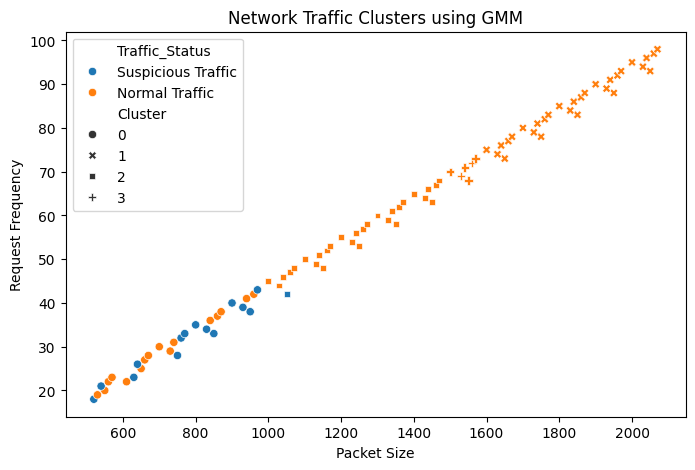

In [14]:
# Step 14 : Cluster Visualization

# Visualizing normal and suspicious traffic.
plt.figure(figsize=(8,5))
sns.scatterplot(
    data = df,
    x = "Packet_Size",
    y = "Request_Frequency",
    hue = "Traffic_Status",
    style = "Cluster"
)
plt.title("Network Traffic Clusters using GMM")
plt.xlabel("Packet Size")
plt.ylabel("Request Frequency")
plt.savefig("images/gmm_network_traffic_clusters.png" , dpi = 300)  # Save the plot
plt.show()
plt.close()

In [15]:
# Step 15 : Cluster Profilling

# Understanding average behavior of each cluster.
cluster_profile = df.groupby("Cluster")[features].mean().round(2)  # Get the average values of features for each cluster

print(cluster_profile)  # Display the cluster profile

         Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
Cluster                                                                       
0             742.67              30.43                48.67            0.4   
1            1841.67              85.50               156.17            8.0   
2            1241.67              55.47                96.17            4.0   
3            1541.67              70.50               126.17            5.0   

         Data_Transfer  
Cluster                 
0              3065.00  
1             11950.00  
2              6950.00  
3              9433.33  


In [16]:
# Step 16 Final Model Evaluation

labels = df["Cluster"]  # Get the cluster labels from the dataframe

silhouette = silhouette_score(X_scaled , labels)
db_score = davies_bouldin_score(X_scaled , labels)
ch_score = calinski_harabasz_score(X_scaled , labels)

print("Final Silhouette Score : " , round(silhouette , 3))
print("Final Davies - Bouldin Score : ", round(db_score , 3))
print("Final Calinski - Harabasz Score : " , round(ch_score , 3))

Final Silhouette Score :  0.39
Final Davies - Bouldin Score :  0.56
Final Calinski - Harabasz Score :  274.884


In [17]:
# Step 17 : Cybersecurity Segment Naming 

# Giving business / security meaning to each cluster 
profile = df.groupby("Cluster")[features].mean()  # Get the average values of features for each cluster

segment_names = {}

avg_request = profile["Request_Frequency"].mean()  # Calculate the average request frequency across clusters
avg_failed = profile["Failed_Logins"].mean()  # Calculate the average failed logins across clusters
avg_transfer = profile["Data_Transfer"].mean()  # Calculate the average data transfer across clusters

for cluster in profile.index :
    request = profile.loc[cluster, "Request_Frequency"]
    failed = profile.loc[cluster , "Failed_Logins"]
    transfer = profile.loc[cluster , "Data_Transfer"]
    
    if request >= avg_request and failed >= avg_failed and transfer >= avg_transfer:
        segment_names[cluster] = "High Risk Suspicious Traffic"
        
    elif request >=  avg_request and failed < avg_failed:
        segment_names[cluster] = "High Activity Normal Traffic"
    
    elif request < avg_request and transfer < avg_transfer:
        segment_names[cluster] = "Low Activity Normal Traffic"
        
    else:
        segment_names[cluster] = "Moderate Risk Traffic"

df["Traffic_Segment"] = df["Cluster"].map(segment_names)  # Map the cluster labels to segment names

print(df[[
    "Packet_Size",
    "Request_Frequency",
    "Connection_Duration",
    "Failed_Logins",
    "Data_Transfer",
    "Cluster",
    "Traffic_Segment",
    "Alert",
    "Traffic_Status"
]].head())  # Display the relevant columns of the updated dataframe with traffic segments

print("\nTraffic Segment Counts :\n", df["Traffic_Segment"].value_counts())  # Display the count of samples in each traffic segment
print("\nAlert Counts :\n", df["Alert"].value_counts())  # Display the count of alerts for suspicious traffic

   Packet_Size  Request_Frequency  Connection_Duration  Failed_Logins  \
0          520                 18                   25              0   
1          610                 22                   35              1   
2          700                 30                   45              0   
3          800                 35                   50              1   
4          900                 40                   60              0   

   Data_Transfer  Cluster              Traffic_Segment  Alert  \
0           2100        0  Low Activity Normal Traffic      1   
1           2400        0  Low Activity Normal Traffic      0   
2           3000        0  Low Activity Normal Traffic      0   
3           3500        0  Low Activity Normal Traffic      1   
4           4000        0  Low Activity Normal Traffic      1   

       Traffic_Status  
0  Suspicious Traffic  
1      Normal Traffic  
2      Normal Traffic  
3  Suspicious Traffic  
4  Suspicious Traffic  

Traffic Segment Counts :


#### **Business Impact :**


* Detects suspicious network activity early
* Improves overall network security
* Reduces manual monitoring effort
* Helps prevent financial loss from cyber attacks
* Segments traffic into actionable risk categories
* Enables data-driven security decisions

#### **Project Conclusion :** 

I built an anomaly detection system using
Gaussian Mixture Model
to identify abnormal network behavior.

* I successfully detected hidden patterns without labeled data
* I classified traffic into High, Medium, and Low risk
* This project demonstrates the power of unsupervised learning in cybersecurity
* It can be extended into a real-time intrusion detection system